In [12]:
import pandas as pd 
from huggingface_hub import hf_hub_download


REPO = "open-spaced-repetition/anki-revlogs-10k"
REVISION = "75299740cff05894ef42d7ad990666691efdd2da"


user_ids = [1, 2, 3, 4]
frames = []

for user_id in user_ids:
    path = hf_hub_download(repo_id=REPO, filename=f"revlogs/user_id={user_id}/data.parquet", repo_type="dataset", revision=REVISION)
    user_df = pd.read_parquet(path)

    frames.append(user_df)

df = pd.concat(frames, ignore_index=True)

df.head(20)

# day_offset: Number of days since the start of user's first review
# rating: User's rating of their recall performance (1: again, 2: hard, 3: good, 4: easy)
# state: Card's learning state (0: new, 1: learning, 2: review, 3: relearning)
# duration: Time spent on the card review in milliseconds (range: 0-60000)
# elapsed_days: Days since the last review (-1 for new cards)
# elapsed_seconds: Seconds since the last review (-1 for new cards)

,card_id,day_offset,rating,state,duration,elapsed_days,elapsed_seconds
0,0,0,3,0,6765,-1,-1
1,0,1,1,1,18663,1,85849
2,1,1,3,0,41170,-1,-1
3,2,1,1,0,19236,-1,-1
4,3,1,1,0,12687,-1,-1
5,0,2,1,1,3705,1,65303
6,2,2,1,1,2028,1,65244
7,3,2,1,1,1957,1,65234
8,1,2,1,1,1737,1,65267
9,6,2,1,0,1654,-1,-1


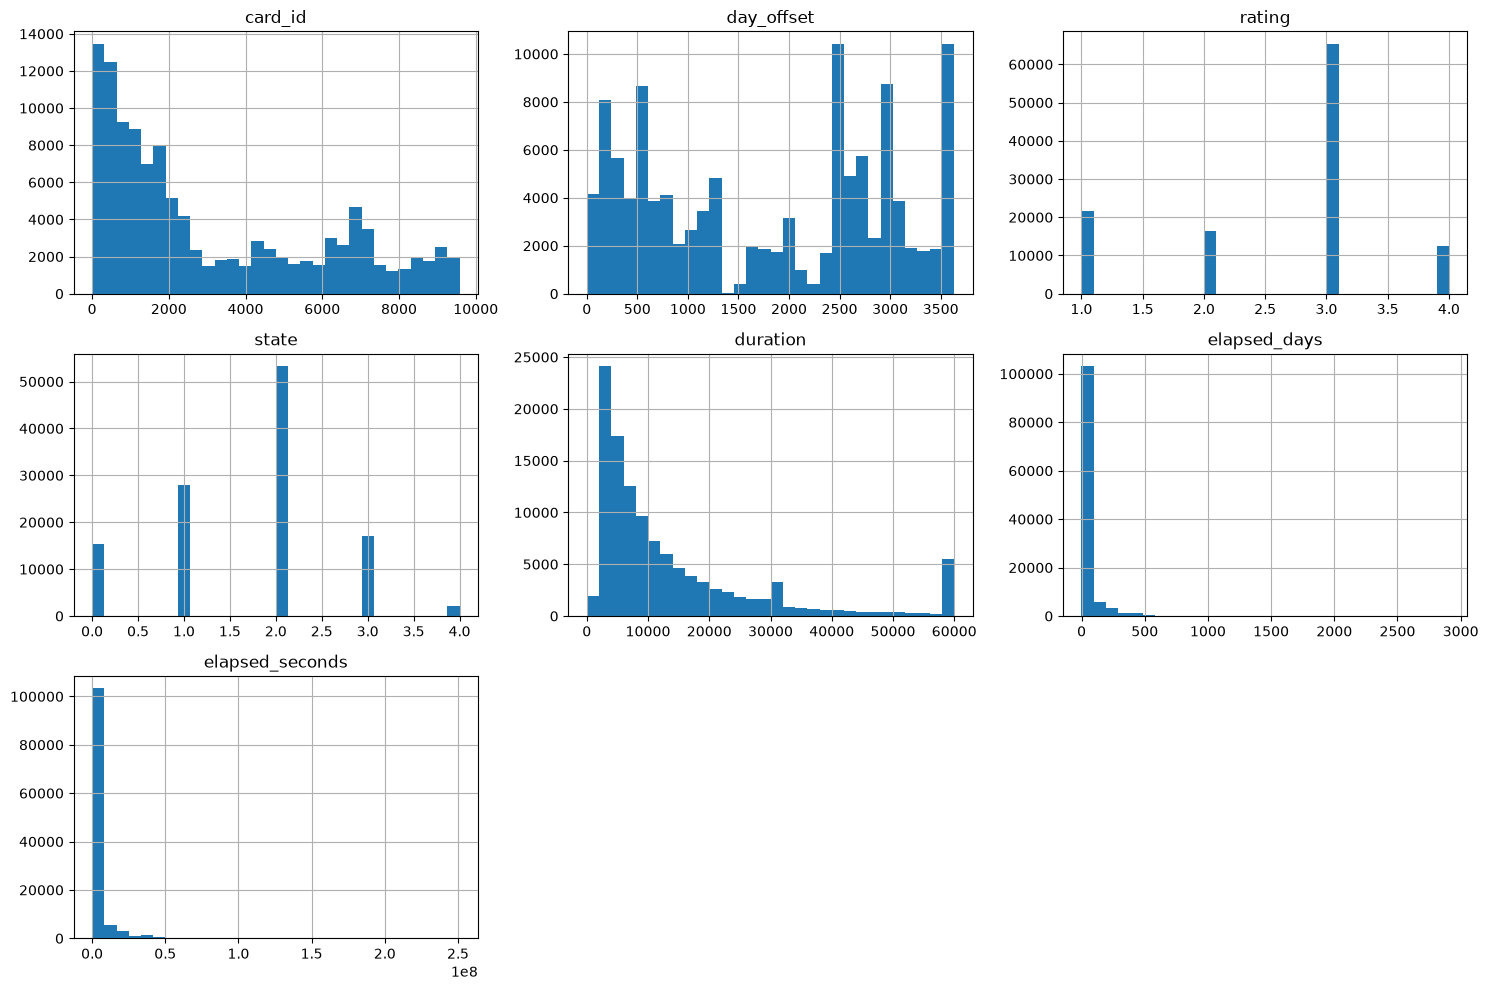

In [13]:
import matplotlib.pyplot as plt

df.hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()

# day_offset: Number of days since the start of user's first review
# rating: User's rating of their recall performance (1: again, 2: hard, 3: good, 4: easy)
# state: Card's learning state (0: new, 1: learning, 2: review, 3: relearning)
# duration: Time spent on the card review in milliseconds (range: 0-60000)
# elapsed_days: Days since the last review (-1 for new cards)
# elapsed_seconds: Seconds since the last review (-1 for new cards)

# cauda longa em duration (provavelmente a gente vai ter que ignorar dps de um dado momento porque a pessoa
# provavelmente deixou aberto sem querer), mas vi também que outro usuário tem state 4, que não é documentado...
# provavelmente vou descartar nos dados. 

In [14]:
df.describe()

,card_id,day_offset,rating,state,duration,elapsed_days,elapsed_seconds
count,115738.000000,115738.000000,115738.000000,115738.000000,115738.000000,115738.000000,1.157380e+05
mean,3106.964048,1802.980681,2.595492,1.678472,14071.648707,39.717854,3.443265e+06
std,2849.355892,1192.102241,0.910728,0.944195,14596.568188,118.645235,1.024781e+07
min,0.000000,0.000000,1.000000,0.000000,0.000000,-1.000000,-1.000000e+00
25%,736.000000,573.000000,2.000000,1.000000,4278.000000,0.000000,5.600000e+02
50%,1863.000000,1948.000000,3.000000,2.000000,8350.000000,2.000000,1.691590e+05
75%,5539.000000,2842.000000,3.000000,2.000000,17707.000000,21.000000,1.813939e+06
max,9578.000000,3634.000000,4.000000,4.000000,60000.000000,2907.000000,2.510854e+08


<Axes: xlabel='state', ylabel='count'>

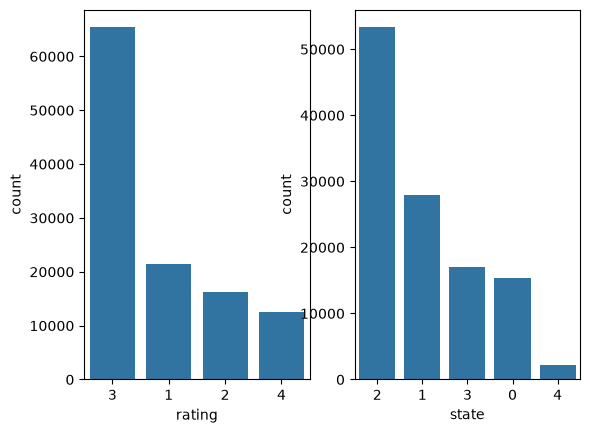

In [15]:
import seaborn as sns

fig, axes = plt.subplots(1, 2)

sns.countplot(data=df, x='rating', order=df['rating'].value_counts().index, ax=axes[0])
sns.countplot(data=df, x='state', order=df['state'].value_counts().index, ax=axes[1])


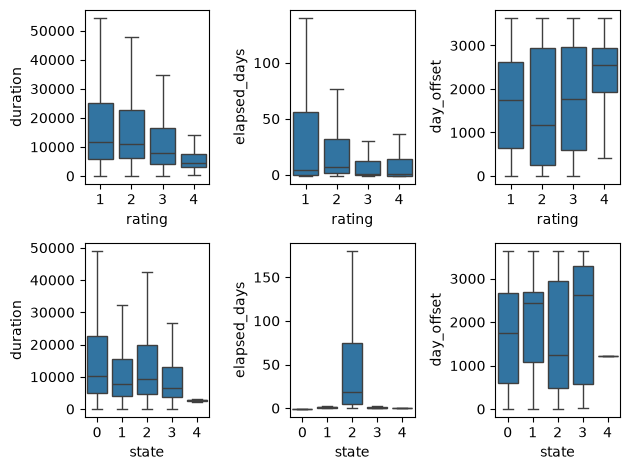

In [ ]:
num_cols = ["duration", "elapsed_days", "day_offset"]

fig, axes = plt.subplots(2, 3)

for i, cat in enumerate(["rating", "state"]):
    for j, num in enumerate(num_cols):
        sns.boxplot(data=df, x=cat, y=num, ax=axes[i, j], showfliers=False)

plt.tight_layout()

# day_offset: Number of days since the start of user's first review
# rating: User's rating of their recall performance (1: again, 2: hard, 3: good, 4: easy)
# state: Card's learning state (0: new, 1: learning, 2: review, 3: relearning)
# duration: Time spent on the card review in milliseconds (range: 0-60000)
# elapsed_days: Days since the last review (-1 for new cards)
# elapsed_seconds: Seconds since the last review (-1 for new cards)